<a href="https://colab.research.google.com/github/venkateshvaddi/Ml-lab/blob/main/program7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error



In [3]:

df = pd.read_csv('/content/drive/MyDrive/testdata.csv')
df.head()

,Sl. No,Temperature,Preasure
0,1,2,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900


In [4]:
temperature = df.iloc[:, 1:2].values #Input
preasure = df.iloc[:, 2].values #output


linreg = LinearRegression()
linreg.fit(temperature, preasure) #fit the model

LinearRegression()

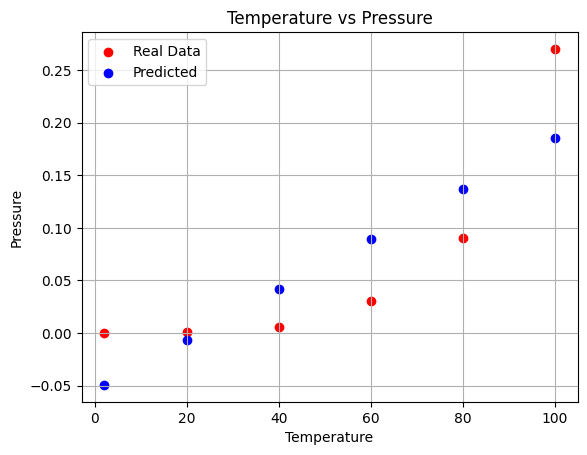

In [5]:
#predict the output
predicted = linreg.predict(temperature)
#plot the results
plt.scatter(temperature, preasure, color='red')
plt.scatter(temperature, predicted, color='blue')
plt.title('Temperature vs Pressure')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.legend(['Real Data', 'Predicted'])
plt.grid()
plt.show()



In [6]:
# Display the coefficients and intercept
print(f"Coefficient (slope): {linreg.coef_[0]}")
print(f"Intercept: {linreg.intercept_}")

Coefficient (slope): 0.0023902890739833406
Intercept: -0.05407788339049481


In [7]:
# Compute Mean Absolute Error (MAE)
mae = mean_absolute_error(preasure, predicted)
print(f"Mean Absolute Error (MAE): {mae}")


Mean Absolute Error (MAE): 0.047339461048505636


In [8]:
#predict the output for new given data ie given temperature is 30

given_temperature = np.array([[30]])
predicted_pressure = linreg.predict(given_temperature)
print(f"Predicted pressure for the given temperature {given_temperature[0][0]}: {predicted_pressure[0]}")


Predicted pressure for the given temperature 30: 0.017630788829005414


In [9]:
# Using the coefficients and intercept to predict the pressure for a temperature of 30

predicted_pressure_compute =  linreg.coef_[0] * given_temperature+ linreg.intercept_
print(f"predicted pressure computed using coefficient and intercept: {predicted_pressure_compute}")

predicted pressure computed using coefficient and intercept: [[0.01763079]]


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.model_selection import train_test_split


# --- Load Temperature-Pressure Data ---
df = pd.read_csv('/content/drive/MyDrive/testdata.csv')


temperature = df.iloc[:, 1:2].values  # Input (2D array)
pressure = df.iloc[:, 2].values       # Output (1D array)

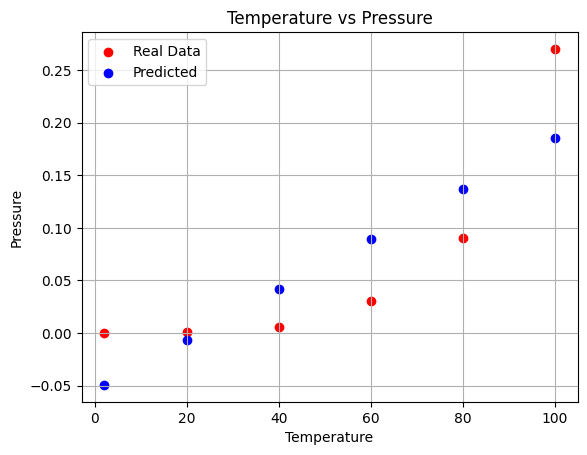

In [11]:
# --- Simple Linear Regression ---
linreg = LinearRegression()
linreg.fit(temperature, pressure)
predicted = linreg.predict(temperature)



# --- Plotting ---
plt.scatter(temperature, pressure, color='red')
plt.scatter(temperature, predicted, color='blue')
plt.title('Temperature vs Pressure')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.legend(['Real Data', 'Predicted'])
plt.grid(True)
plt.show()



In [12]:
# --- Coefficient and Intercept ---
print(f"Coefficient (slope): {linreg.coef_[0]}")
print(f"Intercept: {linreg.intercept_}")


Coefficient (slope): 0.0023902890739833406
Intercept: -0.05407788339049481


In [13]:
# --- Predict Pressure for Given Temperature = 30 and 40 ---
for temp in [30, 40]:
    given_temp = np.array([[temp]])
    predicted_p = linreg.predict(given_temp)[0]
    predicted_p_formula = linreg.coef_[0] * temp + linreg.intercept_
    print(f"\nPredicted pressure for Temperature = {temp}: {predicted_p}")
    print(f"Computed using formula: {predicted_p_formula}")



Predicted pressure for Temperature = 30: 0.017630788829005414
Computed using formula: 0.017630788829005414

Predicted pressure for Temperature = 40: 0.04153367956883881
Computed using formula: 0.04153367956883881


In [14]:
# --- Evaluation Metrics ---
mae = mean_absolute_error(pressure, predicted)
mse = mean_squared_error(pressure, predicted)
rmse = np.sqrt(mse)
rel_mse = mse / np.mean(pressure ** 2)
cv = np.std(pressure) / np.mean(pressure)

print(f"\nEvaluation Metrics:")
print(f"MAE:  {mae:.6f}")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"RelMSE: {rel_mse:.6f}")
print(f"CV (Coefficient of Variation): {cv:.6f}")



Evaluation Metrics:
MAE:  0.047339
MSE:  0.002791
RMSE: 0.052829
RelMSE: 0.204371
CV (Coefficient of Variation): 1.453614


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures



df = pd.read_csv('/content/drive/MyDrive/testdata.csv')
df.head()

,Sl. No,Temperature,Preasure
0,1,2,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900


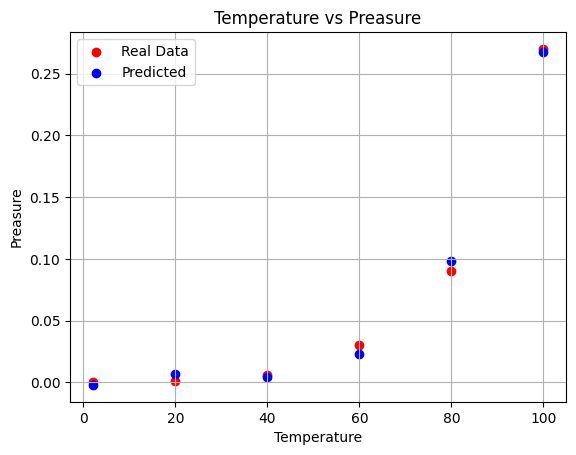

In [16]:
temperature = df.iloc[:, 1:2].values #Input
preasure = df.iloc[:, 2].values #output


polyreg = PolynomialFeatures(degree=3)
X_poly = polyreg.fit_transform(temperature) #Transforming the input data into polynomial features
linreg = LinearRegression()
linreg.fit(X_poly, preasure) #Fitting the model with the transformed data
#Predicting the output with the transformed input data
predicted_preasure = linreg.predict(X_poly)

#Visualising the results
plt.scatter(temperature, preasure, color='red')
plt.scatter(temperature, predicted_preasure, color='blue')
plt.title('Temperature vs Preasure')
plt.xlabel('Temperature')
plt.ylabel('Preasure')
plt.legend(['Real Data', 'Predicted'])
plt.grid()
plt.show()

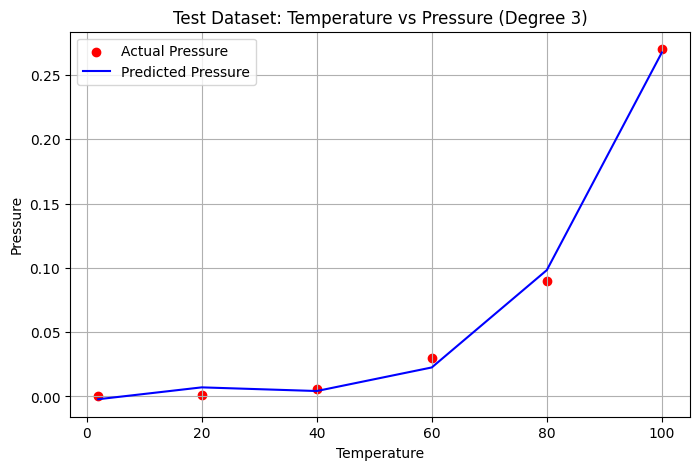

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


# Load test data from local CSV (make sure 'testdata.csv' is in the same directory)
df = pd.read_csv('/content/drive/MyDrive/testdata.csv')
temperature = df.iloc[:, 1:2].values  # Input
pressure = df.iloc[:, 2].values      # Output
# Change degree here to see effect
degree_test = 3
poly_test = PolynomialFeatures(degree=degree_test)
X_poly_test = poly_test.fit_transform(temperature)

model_test = LinearRegression()
model_test.fit(X_poly_test, pressure)
predicted_pressure = model_test.predict(X_poly_test)


# Visualize Test Data Fit
plt.figure(figsize=(8, 5))
plt.scatter(temperature, pressure, color='red', label='Actual Pressure')
plt.plot(temperature, predicted_pressure, color='blue', label='Predicted Pressure')
plt.title(f'Test Dataset: Temperature vs Pressure (Degree {degree_test})')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Load Auto MPG dataset from UCI
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model year', 'origin', 'car name']
df_auto = pd.read_csv(url, names=columns, delim_whitespace=True, na_values='?')
df_auto.dropna(inplace=True)

<ipython-input-18-c527e429b809>:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_auto = pd.read_csv(url, names=columns, delim_whitespace=True, na_values='?')


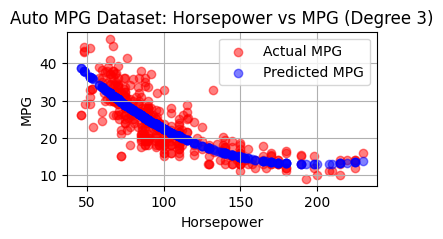

In [19]:

# Input and Output
X = df_auto[['horsepower']].values
y = df_auto['mpg'].values


# Change degree here to see effect
degree_auto = 3
poly_auto = PolynomialFeatures(degree=degree_auto)
X_poly_auto = poly_auto.fit_transform(X)

model_auto = LinearRegression()
model_auto.fit(X_poly_auto, y)
predicted_mpg = model_auto.predict(X_poly_auto)


# Visualize Auto MPG Fit
plt.figure(figsize=(4, 2))
plt.scatter(X, y, color='red', label='Actual MPG', alpha=0.5)
plt.scatter(X, predicted_mpg, color='blue', label='Predicted MPG', alpha=0.5)
plt.title(f'Auto MPG Dataset: Horsepower vs MPG (Degree {degree_auto})')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.grid(True)
plt.show()